# Lecture 5: Medical Evidence — The Mathematics Behind the Chart

**Cholesterol, LDL/HDL, and sugar.** A health editor asks us to assess three persuasive claims. We reconstruct authentic study tables, calculate effects, and repair incomplete figures.

The notebook follows **predict, calculate, plot, interpret**. The instructor runs the demonstration. Students calculate and defend figures on paper.

Our evidence comes from [HPS](https://doi.org/10.1016/S0140-6736(02)09327-3), [AIM-HIGH](https://doi.org/10.1056/NEJMoa1107579), and the [NHANES added-sugar mortality study](https://doi.org/10.1001/jamainternmed.2013.13563). These are published aggregate tables, not individual patient records. The endpoints and study designs differ.

**Final question:** Can sugar's risk make LDL harmless? Does raising HDL guarantee protection?

In [1]:
# Google Colab setup. Locally, open this notebook beside data/.
import sys, subprocess
from pathlib import Path
if 'google.colab' in sys.modules:
    repo = Path('/content/teaching-lecture5')
    if not (repo / '.git').exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/DrFarrukh/teaching.git',str(repo)], check=True)
    import os
    os.chdir(repo / 'courses/data-analysis-and-visualization/lectures/lecture-05')
    subprocess.run([sys.executable,'-m','pip','install','-q','-r','requirements.txt'],check=True)

## RUN 0: Source tables and checks

**Predict:** What does a row represent? Which counts can be added? Which summaries cannot recover individual patients?

The study dictionary gives units, population, outcome, and model definition. A confidence interval is a different object from a standard deviation or an interquartile range.

In [2]:
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import norm
from IPython.display import display

BASE = Path.cwd()
DATA = BASE / 'data'
OUT = BASE / 'outputs'
FIG = OUT / 'figures'
FIG.mkdir(parents=True,exist_ok=True)
tables = {p.stem:pd.read_csv(p) for p in sorted(DATA.glob('*.csv'))}
events=tables['trial_events']; subgroups=tables['hps_subgroups']
lipids=tables['aim_high_lipids']; sugar=tables['sugar_estimates']
assert not events.duplicated(['study','arm','outcome']).any()
assert ((events.events>=0)&(events.events<=events.n)).all()
for family,g in subgroups.groupby('partition'):
    summed=g.groupby('arm')[['n','events']].sum()
    assert list(summed.loc['Simvastatin'])==[10269,2033]
    assert list(summed.loc['Placebo'])==[10267,2585]
print('Every HPS subgroup family separately reproduces the overall counts.')
display(pd.DataFrame([{'table':k,'rows':len(v),'columns':len(v.columns)} for k,v in tables.items()]))
display(events[['study','arm','n','events','outcome']])

Every HPS subgroup family separately reproduces the overall counts.


,table,rows,columns
0,aim_high_lipids,24,13
1,aim_high_reported_changes,2,5
2,hps_subgroups,22,10
3,reported_effects,2,7
4,sugar_estimates,10,12
5,trial_events,18,8


,study,arm,n,events,outcome
0,HPS,Simvastatin,10269,2033,Major vascular event
1,HPS,Placebo,10267,2585,Major vascular event
2,HPS,Simvastatin,10269,898,Major coronary event
3,HPS,Placebo,10267,1212,Major coronary event
4,HPS,Simvastatin,10269,444,Stroke
5,HPS,Placebo,10267,585,Stroke
6,HPS,Simvastatin,10269,939,Revascularization
7,HPS,Placebo,10267,1205,Revascularization
8,HPS,Simvastatin,10269,1328,All-cause death
9,HPS,Placebo,10267,1507,All-cause death


## Plotting and analytical helpers

Each figure exports its exact plotted values to `outputs/chart_data.json`. PowerPoint charts use the same values. The code keeps source facts, count-based calculations, and teaching illustrations identifiable.

In [3]:
C={'control':'#253B53','treatment':'#087E8B','niacin':'#7657A0','sugar':'#D37D24','muted':'#CBD5DE','text':'#203247'}
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':13,'axes.spines.top':False,
    'axes.spines.right':False,'axes.labelcolor':C['text'],'text.color':C['text'],
    'axes.titleweight':'bold','figure.facecolor':'white','axes.facecolor':'white'})
CHARTS={}

def comparison(study,outcome,treatment,control):
    g=events[(events.study==study)&(events.outcome==outcome)].set_index('arm')
    nt,et=float(g.loc[treatment,'n']),float(g.loc[treatment,'events'])
    nc,ec=float(g.loc[control,'n']),float(g.loc[control,'events'])
    pt,pc=et/nt,ec/nc
    arr=pc-pt; se=np.sqrt(pc*(1-pc)/nc+pt*(1-pt)/nt)
    rr=pt/pc; selog=np.sqrt(1/et-1/nt+1/ec-1/nc)
    return dict(study=study,outcome=outcome,nt=nt,nc=nc,et=et,ec=ec,pt=pt,pc=pc,
        arr=arr,arr_low=arr-1.96*se,arr_high=arr+1.96*se,se=se,
        rr=rr,rr_low=np.exp(np.log(rr)-1.96*selog),rr_high=np.exp(np.log(rr)+1.96*selog),
        rrr=1-rr,logrr_se=selog)

def series(name,values,color,x=None,lower=None,upper=None):
    d={'name':name,'values':np.asarray(values,dtype=float).tolist(),'color':color}
    if x is not None:d['x']=np.asarray(x,dtype=float).tolist()
    if lower is not None:d['lower']=np.asarray(lower,dtype=float).tolist()
    if upper is not None:d['upper']=np.asarray(upper,dtype=float).tolist()
    return d

def draw_panel(ax,p):
    kind=p['kind']; ss=p.get('series',[])
    if kind=='bar':
        cats=p['categories']; x=np.arange(len(cats)); w=.72/max(1,len(ss))
        for j,s in enumerate(ss):
            xx=x+(j-(len(ss)-1)/2)*w
            bars=ax.bar(xx,s['values'],w,color=s.get('colors',s['color']),label=s['name'])
            if p.get('labels',True):
                ax.bar_label(bars,labels=[f"{v:.1f}" if p.get('decimals',1) else f"{v:,.0f}" for v in s['values']],padding=5,fontsize=12)
        ax.set_xticks(x,cats)
    elif kind=='stacked':
        cats=p['categories']; x=np.arange(len(cats)); bottom=np.zeros(len(cats))
        for s in ss:
            bars=ax.bar(x,s['values'],.58,bottom=bottom,color=s['color'],label=s['name'])
            for i,v in enumerate(s['values']):
                if v>3:ax.text(i,bottom[i]+v/2,f'{v:.1f}%',ha='center',va='center',color='white' if s['color']!=C['muted'] else C['text'],fontsize=13)
            bottom+=s['values']
        ax.set_xticks(x,cats)
    elif kind in ['line','points']:
        for s in ss:
            x=s.get('x',list(range(len(s['values'])))); vals=np.array(s['values'])
            if 'lower' in s:
                ax.errorbar(x,vals,yerr=np.array([vals-np.array(s['lower']),np.array(s['upper'])-vals]),
                    fmt='o-' if kind=='line' else 'o',color=s['color'],lw=2,capsize=5,label=s['name'])
            else:ax.plot(x,vals,'o-' if kind=='line' else 'o',color=s['color'],lw=2,label=s['name'])
        if 'xticks' in p:ax.set_xticks(p['xticks'],p.get('xticklabels',p['xticks']))
    elif kind=='forest':
        for s in ss:
            vals=np.array(s['values']); y=np.array(s['y'])
            ax.errorbar(vals,y,xerr=np.array([vals-np.array(s['lower']),np.array(s['upper'])-vals]),fmt='o',
                color=s['color'],lw=2,capsize=5,label=s['name'])
        ax.set_yticks(p['yticks'],p['yticklabels']);ax.invert_yaxis()
    elif kind=='icons':
        # Display coordinates encode 1,000 standardized people, not raw patients.
        x=np.tile(np.arange(50),20); y=np.repeat(np.arange(20),50)
        count=p['affected']
        ax.scatter(x[count:],y[count:],s=12,color=C['muted'],marker='s')
        ax.scatter(x[:count],y[:count],s=12,color=p['color'],marker='s')
        ax.set_aspect('equal');ax.invert_yaxis();ax.axis('off')
    elif kind=='curve':
        for s in ss:ax.plot(s['x'],s['values'],color=s['color'],lw=2,label=s['name'])
    else:raise ValueError(kind)
    if kind!='icons':
        ax.set_xlabel(p.get('xlabel',''));ax.set_ylabel(p.get('ylabel',''))
        ax.grid(axis='x' if kind=='forest' else 'y',alpha=.18)
        if p.get('xscale')=='log':
            ax.set_xscale('log');ax.xaxis.set_major_formatter(ScalarFormatter())
        if p.get('yscale')=='log':
            ax.set_yscale('log');ax.yaxis.set_major_formatter(ScalarFormatter())
        if 'xlim' in p:ax.set_xlim(p['xlim'])
        if 'ylim' in p:ax.set_ylim(p['ylim'])
        if 'xref' in p:ax.axvline(p['xref'],color='#687B8D',ls='--',lw=1)
        if 'yref' in p:ax.axhline(p['yref'],color='#687B8D',ls='--',lw=1)
        if len(ss)>1 and not p.get('hide_legend'):ax.legend(frameon=False,fontsize=10,loc='best')
    ax.set_title(p.get('title',''),fontsize=14,pad=15)

def emit(key,title,panels,caption,source,source_kind='published data'):
    fig,axes=plt.subplots(1,len(panels),figsize=(12,5.6),squeeze=False)
    for ax,p in zip(axes.flat,panels):draw_panel(ax,p)
    fig.suptitle(title,fontsize=18,fontweight='bold',y=.99)
    fig.text(.015,.02,caption,fontsize=10,color='#52687C')
    fig.tight_layout(rect=[0,.08,1,.91])
    fig.savefig(FIG/f'{key}.png',dpi=180,bbox_inches='tight')
    fig.savefig(FIG/f'{key}.svg',bbox_inches='tight')
    CHARTS[key]={'title':title,'panels':panels,'caption':caption,'source':source,'source_kind':source_kind}
    plt.show();plt.close(fig)

hps=comparison('HPS','Major vascular event','Simvastatin','Placebo')
aim=comparison('AIM-HIGH','Primary cardiovascular outcome','Niacin + statin','Placebo + statin')
HPS='https://doi.org/10.1016/S0140-6736(02)09327-3'
AIM='https://doi.org/10.1056/NEJMoa1107579'
SUGAR='https://doi.org/10.1001/jamainternmed.2013.13563'

## RUN 1: The LDL trial's actual counts

**Predict:** Do 2,033 and 2,585 answer a probability question without the denominators?

HPS randomized patients to simvastatin or placebo. Our endpoint is a participant's first major vascular event during the trial period. Components overlap and must not be added. Keep patients in their assigned arms.

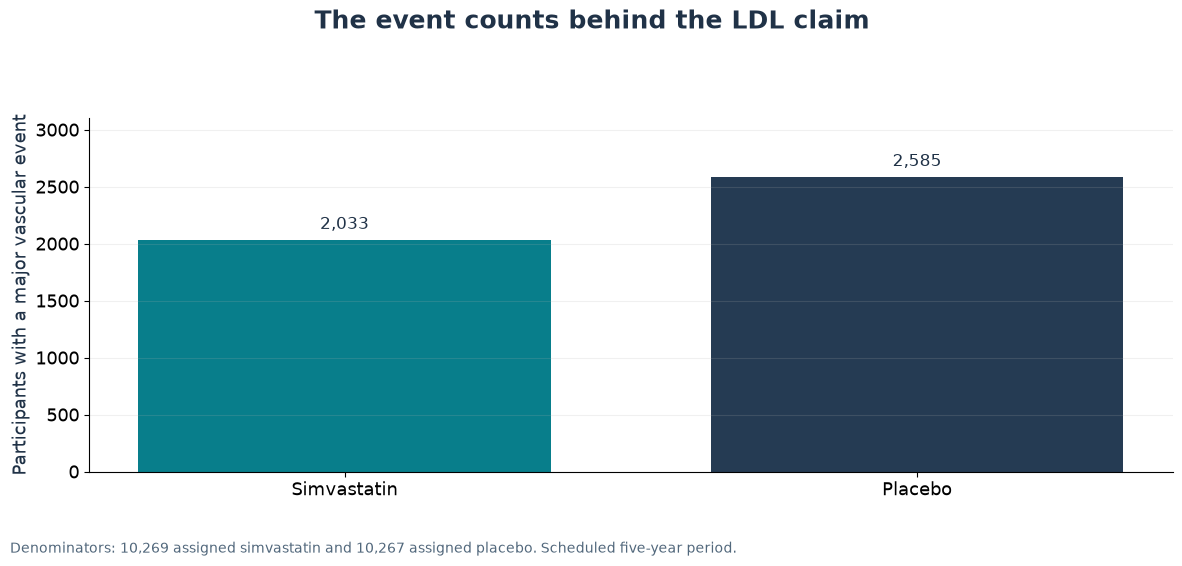

In [4]:
emit('01_hps_counts','The event counts behind the LDL claim',[
    dict(kind='bar',categories=['Simvastatin','Placebo'],ylabel='Participants with a major vascular event',decimals=0,
         series=[dict(series('Events',[hps['et'],hps['ec']],C['treatment']),colors=[C['treatment'],C['control']])],ylim=[0,3100])],
    'Denominators: 10,269 assigned simvastatin and 10,267 assigned placebo. Scheduled five-year period.',HPS)

## RUN 2: Derivation on the board

For binary outcomes $Y_i\sim\operatorname{Bernoulli}(p)$,

$$\hat p=\frac1n\sum_iY_i,\quad E(\hat p)=p,\quad
\operatorname{Var}(\hat p)=\frac1{n^2}\sum_i\operatorname{Var}(Y_i)=\frac{p(1-p)}n.$$

The final equality assumes independent participants. For independent assigned arms:

$$ARR=\hat p_C-\hat p_T,\qquad RR=\frac{\hat p_T}{\hat p_C},\qquad RRR=1-RR.$$

$$SE(ARR)=\sqrt{\frac{\hat p_C(1-\hat p_C)}{n_C}+\frac{\hat p_T(1-\hat p_T)}{n_T}}.$$

**Calculate first:** both risks, ARR in percentage points, RRR in percent, and the estimated difference per 1,000 people.

In [5]:
display(pd.Series({
    'Simvastatin event risk (%)':100*hps['pt'], 'Placebo event risk (%)':100*hps['pc'],
    'Absolute risk reduction (percentage points)':100*hps['arr'],
    'Count-based relative risk reduction (%)':100*hps['rrr'],
    'Fewer affected people per 1,000':1000*hps['arr'],
    'ARR approximate 95% CI lower (pp)':100*hps['arr_low'],
    'ARR approximate 95% CI upper (pp)':100*hps['arr_high']}))

Simvastatin event risk (%)                     19.797449
Placebo event risk (%)                         25.177754
Absolute risk reduction (percentage points)     5.380305
Count-based relative risk reduction (%)        21.369282
Fewer affected people per 1,000                53.803053
ARR approximate 95% CI lower (pp)               4.240623
ARR approximate 95% CI upper (pp)               6.519987
dtype: float64

## RUN 3: An intentionally incomplete scale

**Predict:** With a 19% baseline, how many times taller is the placebo bar?

Visible heights are $p_C-b$ and $p_T-b$. Their ratio is $(p_C-b)/(p_T-b)$, while the event-risk ratio is $p_C/p_T$. This exhibit contains correct percentages but exaggerates their ratio through bar lengths.

Visible height ratio: 7.74689895078007
Actual placebo/treatment risk ratio: 1.2717676119426367


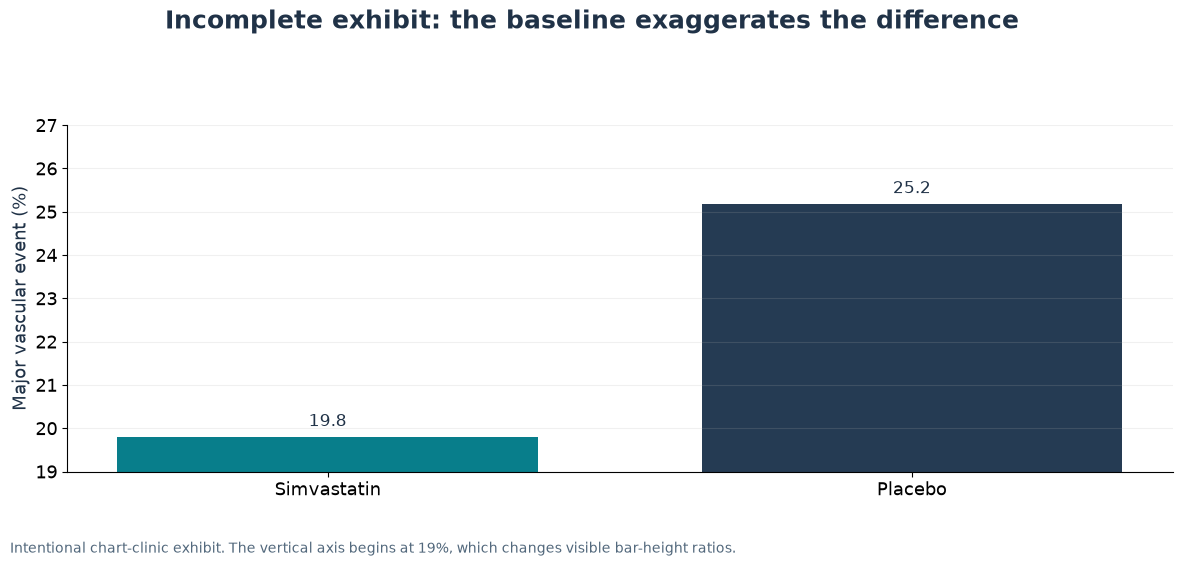

In [6]:
print('Visible height ratio:',(100*hps['pc']-19)/(100*hps['pt']-19))
print('Actual placebo/treatment risk ratio:',hps['pc']/hps['pt'])
emit('02_hps_truncated','Incomplete exhibit: the baseline exaggerates the difference',[
    dict(kind='bar',categories=['Simvastatin','Placebo'],ylabel='Major vascular event (%)',
         series=[dict(series('Event risk',[100*hps['pt'],100*hps['pc']],C['treatment']),colors=[C['treatment'],C['control']])],ylim=[19,27])],
    'Intentional chart-clinic exhibit. The vertical axis begins at 19%, which changes visible bar-height ratios.',HPS)

## RUN 4: Position, length, and the correct comparison

**Explain:** A bar's length encodes magnitude from its baseline. A dot's position can show a restricted range if that range is explicit. Both arms need the same scale and outcome definition.

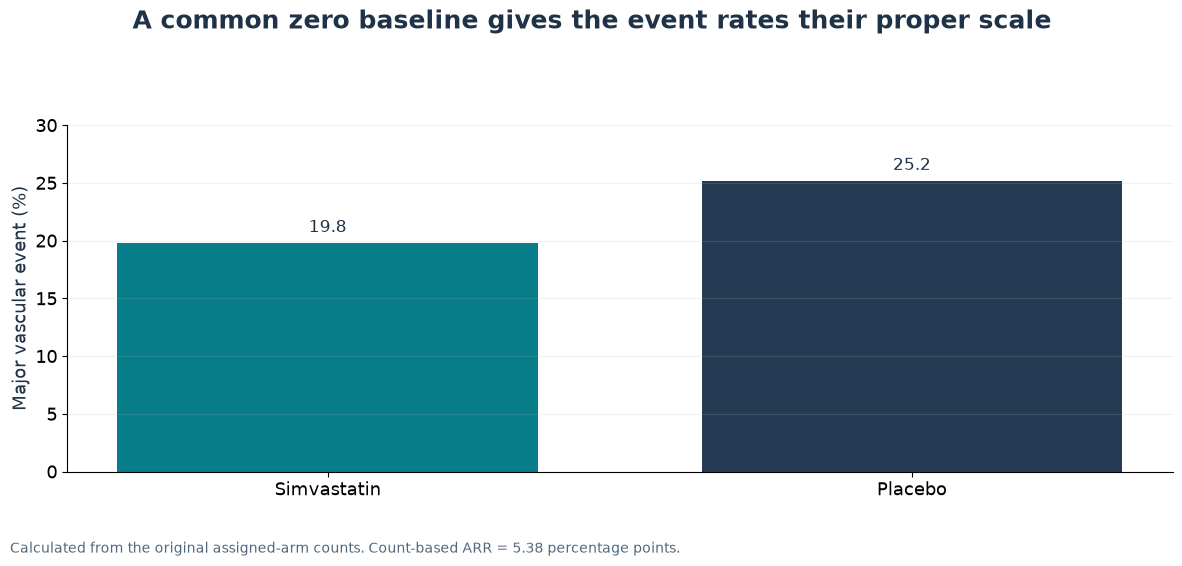

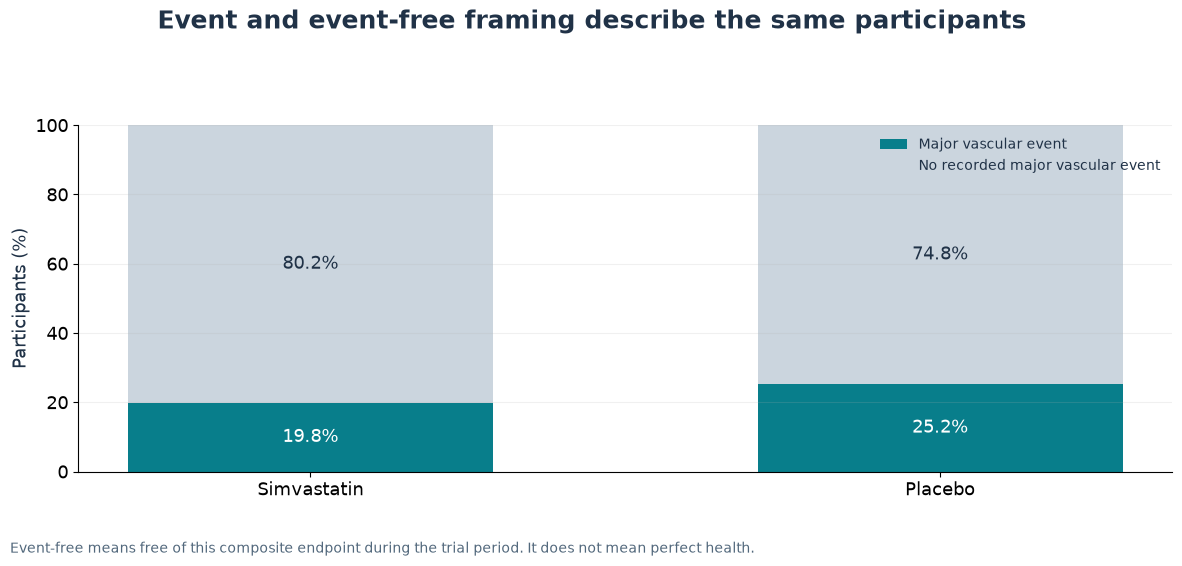

In [7]:
emit('03_hps_zero','A common zero baseline gives the event rates their proper scale',[
    dict(kind='bar',categories=['Simvastatin','Placebo'],ylabel='Major vascular event (%)',
         series=[dict(series('Event risk',[100*hps['pt'],100*hps['pc']],C['treatment']),colors=[C['treatment'],C['control']])],ylim=[0,30])],
    'Calculated from the original assigned-arm counts. Count-based ARR = 5.38 percentage points.',HPS)
emit('04_hps_framing','Event and event-free framing describe the same participants',[
    dict(kind='stacked',categories=['Simvastatin','Placebo'],ylabel='Participants (%)',ylim=[0,100],
         series=[series('Major vascular event',[100*hps['pt'],100*hps['pc']],C['treatment']),
                 series('No recorded major vascular event',[100*(1-hps['pt']),100*(1-hps['pc'])],C['muted'])])],
    'Event-free means free of this composite endpoint during the trial period. It does not mean perfect health.',HPS)

## RUN 5: Absolute benefit made visible

**Predict:** How many fewer affected people does the difference represent per 1,000 comparable participants?

The icon arrays standardize both denominators to 1,000. They are a rounded display of estimated risks, not 2,000 individual records from the trial.

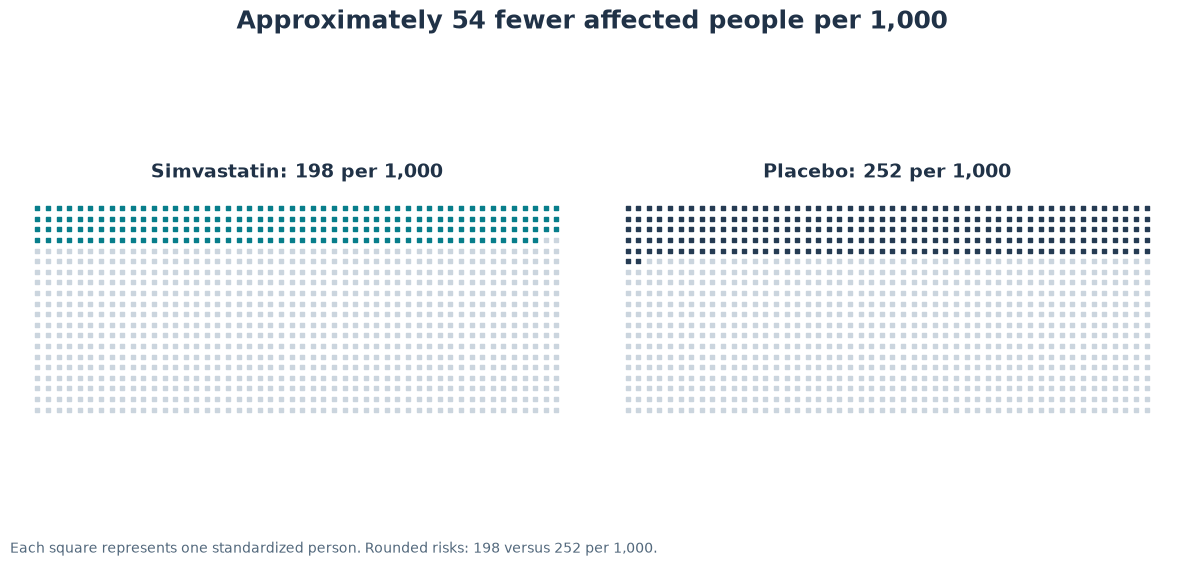

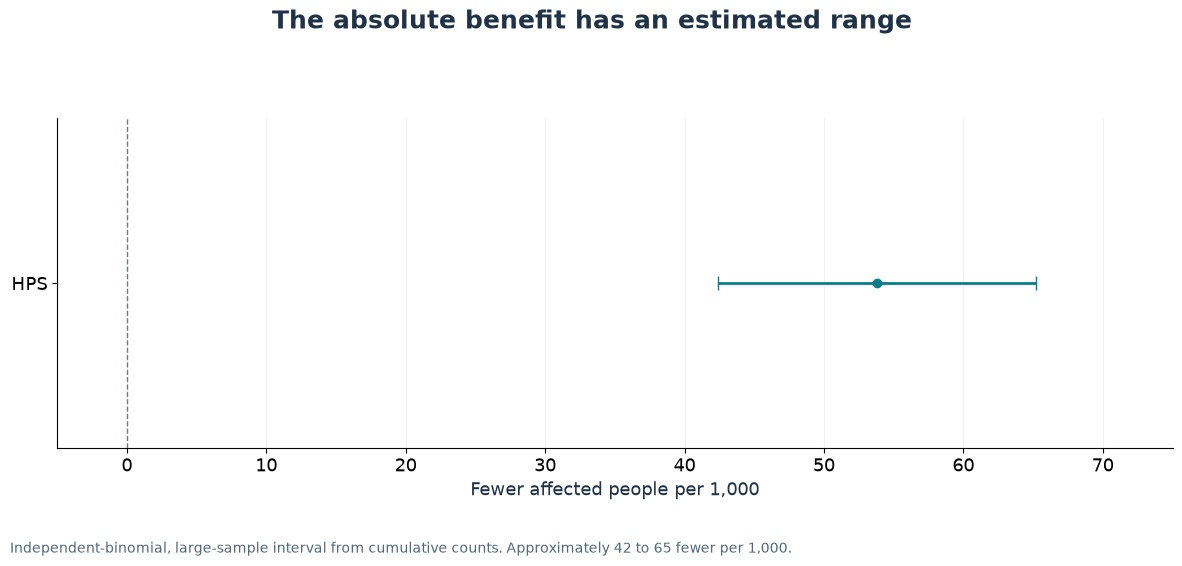

In [8]:
emit('05_hps_icons','Approximately 54 fewer affected people per 1,000',[
    dict(kind='icons',affected=round(1000*hps['pt']),color=C['treatment'],title=f"Simvastatin: {round(1000*hps['pt'])} per 1,000"),
    dict(kind='icons',affected=round(1000*hps['pc']),color=C['control'],title=f"Placebo: {round(1000*hps['pc'])} per 1,000")],
    'Each square represents one standardized person. Rounded risks: 198 versus 252 per 1,000.',HPS)
emit('06_hps_absolute_interval','The absolute benefit has an estimated range',[
    dict(kind='forest',xlabel='Fewer affected people per 1,000',yticks=[0],yticklabels=['HPS'],xref=0,xlim=[-5,75],
         series=[dict(series('Approximate 95% CI',[1000*hps['arr']],C['treatment'],
             lower=[1000*hps['arr_low']],upper=[1000*hps['arr_high']]),y=[0])])],
    'Independent-binomial, large-sample interval from cumulative counts. Approximately 42 to 65 fewer per 1,000.',HPS)

## RUN 6: Sampling uncertainty as a model

The estimated standard error is a measure of the estimator's sampling variation. The following normal curve illustrates the approximation used for the interval. It is not an observed patient distribution and is not a posterior probability for the true effect.

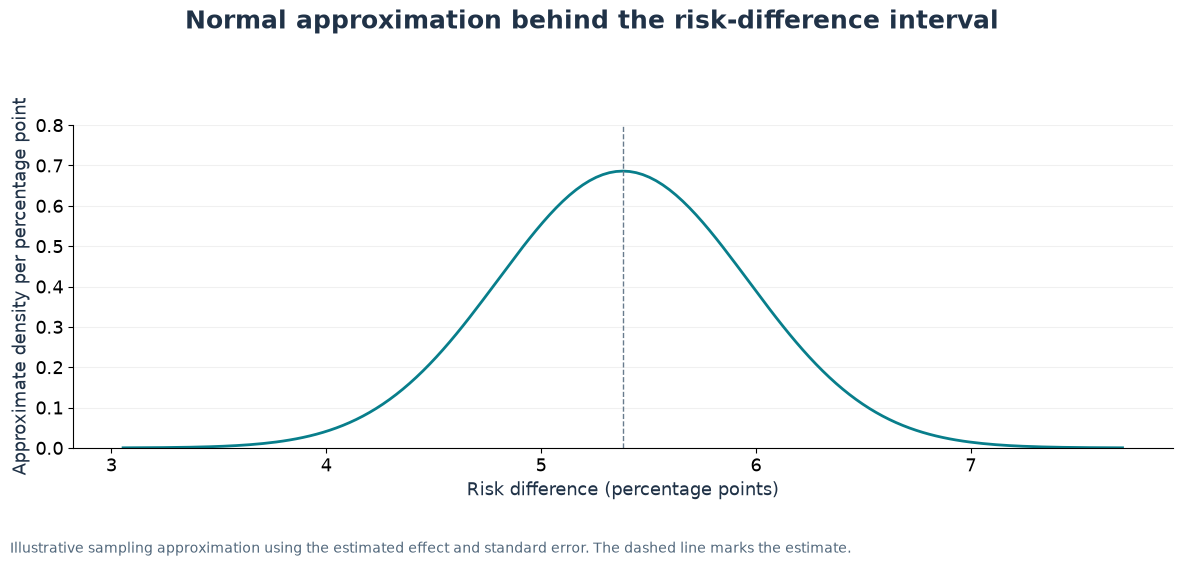

In [9]:
x=np.linspace(100*hps['arr']-4*100*hps['se'],100*hps['arr']+4*100*hps['se'],151)
emit('07_hps_sampling','Normal approximation behind the risk-difference interval',[
    dict(kind='curve',xlabel='Risk difference (percentage points)',ylabel='Approximate density per percentage point',
         series=[series('Normal approximation',norm.pdf(x,loc=100*hps['arr'],scale=100*hps['se']),C['treatment'],x=x)],
         xref=100*hps['arr'],ylim=[0,.8])],
    'Illustrative sampling approximation using the estimated effect and standard error. The dashed line marks the estimate.',HPS,'statistical approximation')

## RUN 7: Does the treatment benefit appear across baseline LDL groups?

**Predict:** Does a screening LDL-C below 3 mmol/L guarantee no benefit in these high-risk patients?

Each LDL group partitions the trial. Treatment comparisons within a group retain randomization. Comparisons between baseline LDL categories remain observational.

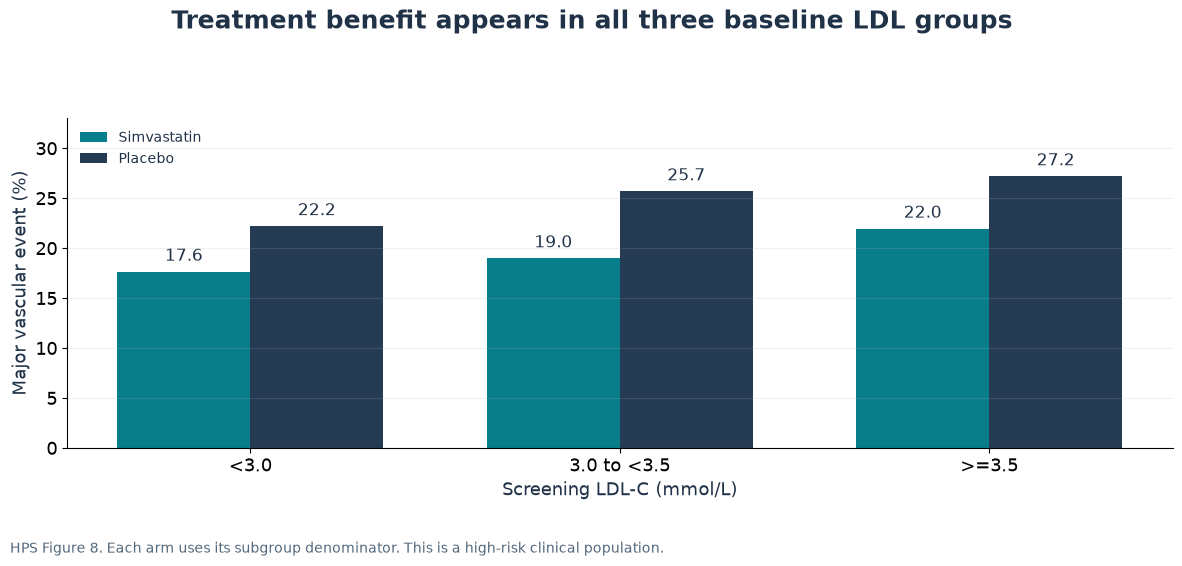

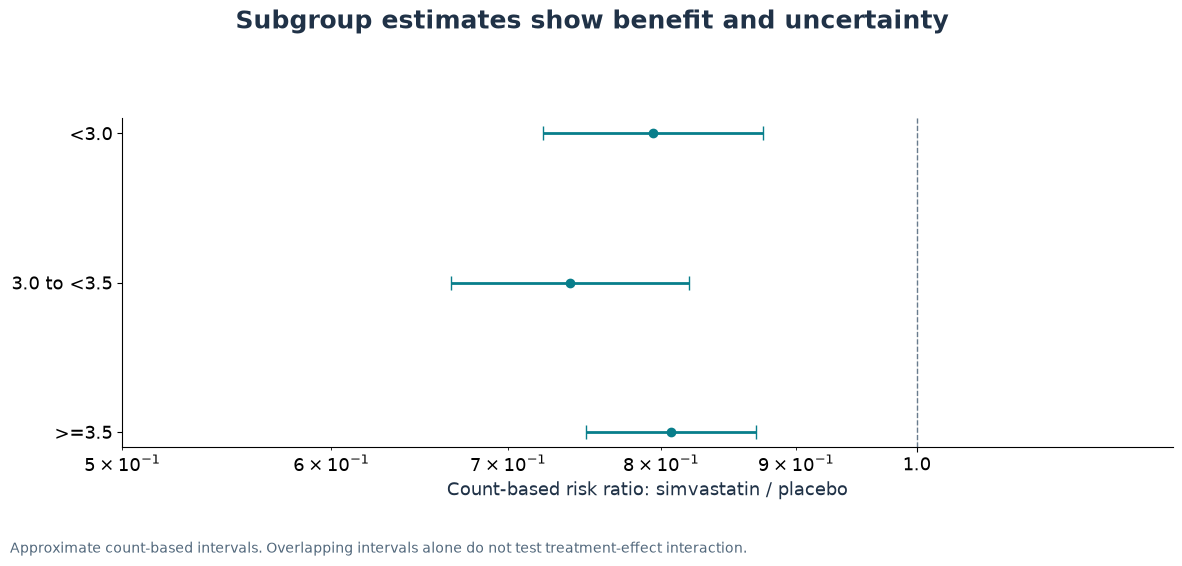

In [10]:
ldl=subgroups[subgroups.partition=='LDL-C (mmol/L)'].sort_values('order')
ldl_groups=ldl.drop_duplicates('group').group.tolist()
rate_series=[]
ldl_effects=[]
for arm,color in [('Simvastatin',C['treatment']),('Placebo',C['control'])]:
    a=ldl[ldl.arm==arm]
    rate_series.append(series(arm,100*a.events/a.n,color))
for label,g in ldl.groupby('group',sort=False):
    a=g.set_index('arm');pt=a.loc['Simvastatin','events']/a.loc['Simvastatin','n'];pc=a.loc['Placebo','events']/a.loc['Placebo','n']
    rr=pt/pc;se=np.sqrt(1/a.loc['Simvastatin','events']-1/a.loc['Simvastatin','n']+1/a.loc['Placebo','events']-1/a.loc['Placebo','n'])
    ldl_effects.append(dict(group=label,rr=rr,low=np.exp(np.log(rr)-1.96*se),high=np.exp(np.log(rr)+1.96*se)))
ldl_effects=pd.DataFrame(ldl_effects)
emit('08_hps_ldl_groups','Treatment benefit appears in all three baseline LDL groups',[
    dict(kind='bar',categories=ldl_groups,ylabel='Major vascular event (%)',xlabel='Screening LDL-C (mmol/L)',series=rate_series,ylim=[0,33])],
    'HPS Figure 8. Each arm uses its subgroup denominator. This is a high-risk clinical population.',HPS)
emit('09_hps_ldl_forest','Subgroup estimates show benefit and uncertainty',[
    dict(kind='forest',xlabel='Count-based risk ratio: simvastatin / placebo',yticks=[0,1,2],yticklabels=ldl_effects.group.tolist(),
        xref=1,xlim=[.5,1.25],xscale='log',series=[dict(series('95% CI',ldl_effects.rr,C['treatment'],lower=ldl_effects.low,upper=ldl_effects.high),y=[0,1,2])])],
    'Approximate count-based intervals. Overlapping intervals alone do not test treatment-effect interaction.',HPS)

## RUN 8: The observational reason HDL looks protective

The placebo arm's event proportions decrease across higher screening HDL groups. This is a real pattern in the trial summaries. Patients were not randomized to these HDL categories.

**Predict:** Does the pattern establish that increasing a patient's HDL will improve their outcome?

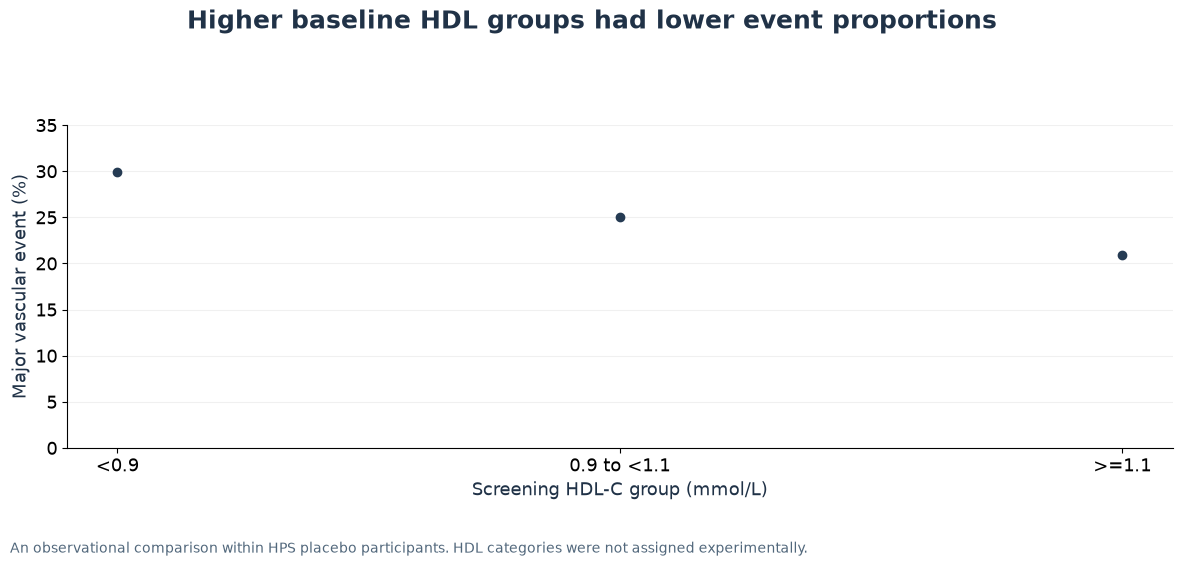

In [11]:
hdl_groups=subgroups[(subgroups.partition=='HDL-C (mmol/L)')&(subgroups.arm=='Placebo')].sort_values('order')
emit('10_hdl_observational','Higher baseline HDL groups had lower event proportions',[
    dict(kind='points',xlabel='Screening HDL-C group (mmol/L)',ylabel='Major vascular event (%)',
        xticks=[0,1,2],xticklabels=hdl_groups.group.tolist(),ylim=[0,35],
        series=[series('HPS placebo arm',100*hdl_groups.events/hdl_groups.n,C['control'],x=[0,1,2])])],
    'An observational comparison within HPS placebo participants. HDL categories were not assigned experimentally.',HPS)

## RUN 9: The HDL pitch

Show the niacin arm alone. Its reported median HDL moves from 35 to 42 mg/dL at two years.

**Commit:** Would you publish a headline claiming fewer heart events from this figure alone?

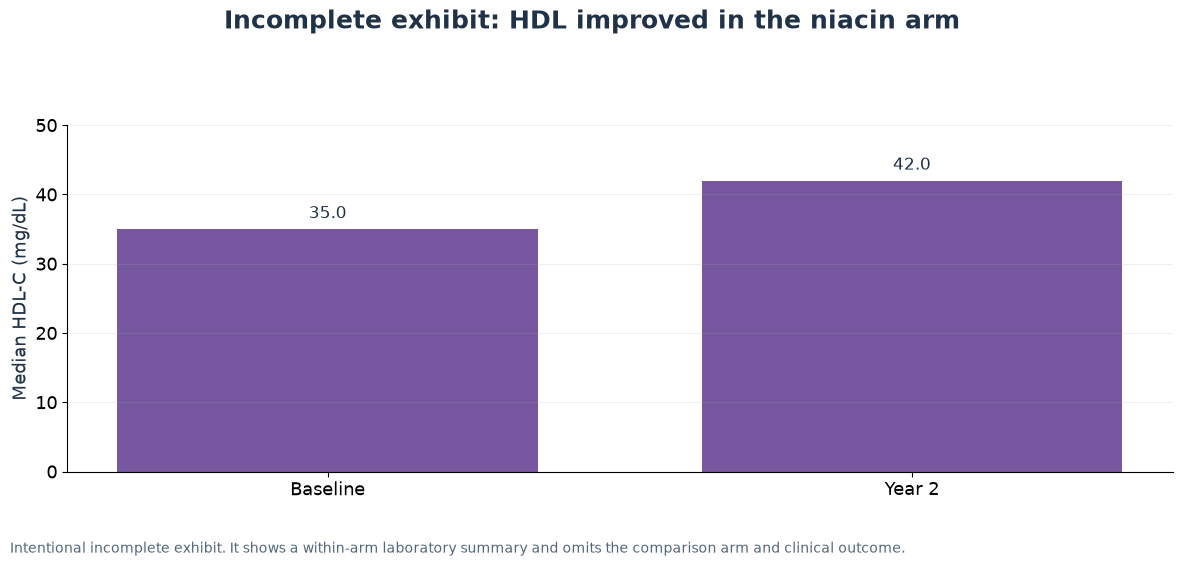

In [12]:
emit('11_hdl_incomplete','Incomplete exhibit: HDL improved in the niacin arm',[
    dict(kind='bar',categories=['Baseline','Year 2'],ylabel='Median HDL-C (mg/dL)',
         series=[series('Niacin + statin',[35,42],C['niacin'])],ylim=[0,50])],
    'Intentional incomplete exhibit. It shows a within-arm laboratory summary and omits the comparison arm and clinical outcome.',AIM)

## RUN 10: The comparison arm and the full timeline

**Explain:** Why is a before-and-after laboratory improvement alone insufficient? Both groups received statin treatment. The randomized comparison concerns the niacin add-on.

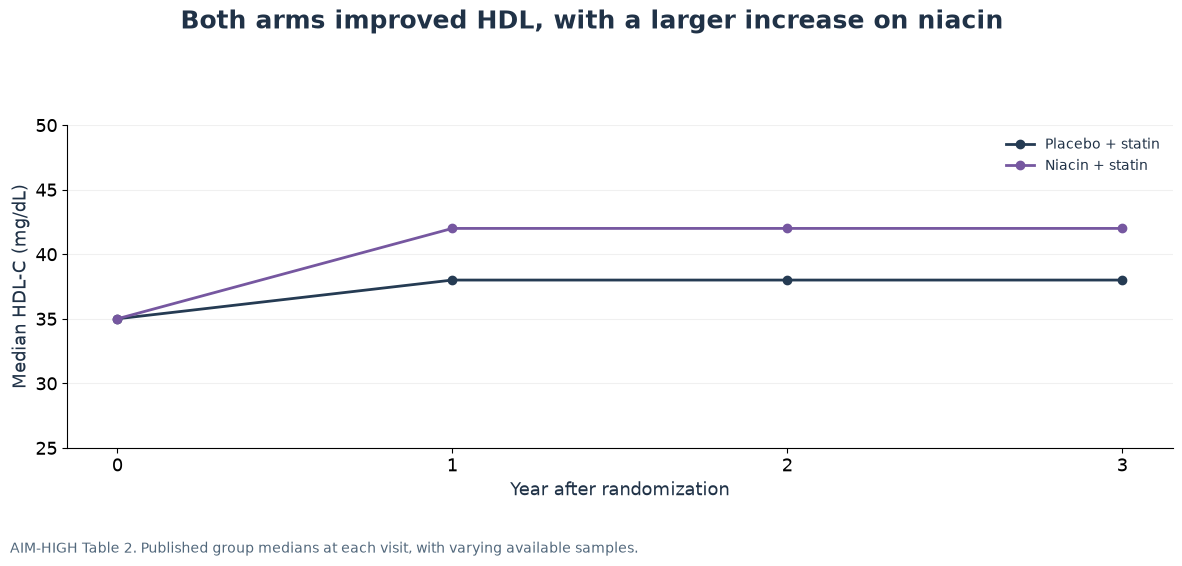

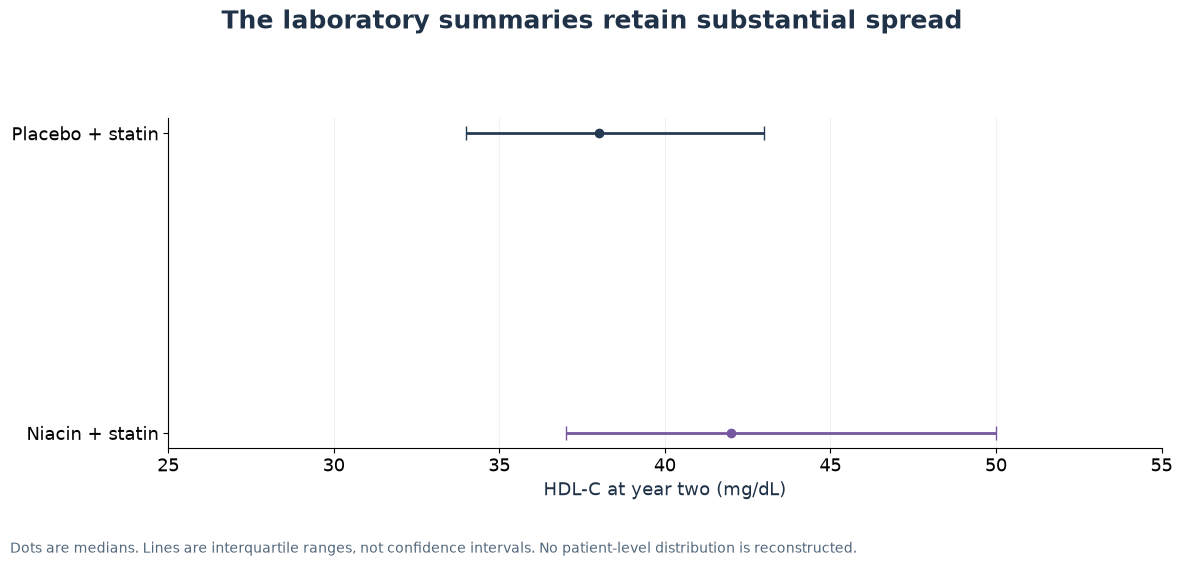

In [13]:
hdl=lipids[lipids.analyte=='HDL-C']
ss=[]
for arm,color in [('Placebo + statin',C['control']),('Niacin + statin',C['niacin'])]:
    g=hdl[hdl.arm==arm].sort_values('year')
    ss.append(series(arm,g['median'],color,x=g.year))
emit('12_hdl_both_arms','Both arms improved HDL, with a larger increase on niacin',[
    dict(kind='line',xlabel='Year after randomization',ylabel='Median HDL-C (mg/dL)',xticks=[0,1,2,3],ylim=[25,50],series=ss)],
    'AIM-HIGH Table 2. Published group medians at each visit, with varying available samples.',AIM)
ss=[]
for arm,color in [('Placebo + statin',C['control']),('Niacin + statin',C['niacin'])]:
    g=hdl[(hdl.arm==arm)&(hdl.year==2)]
    ss.append(dict(series(arm,g['median'],color,lower=g.q1,upper=g.q3),y=[0 if arm=='Placebo + statin' else 1]))
emit('13_hdl_iqr','The laboratory summaries retain substantial spread',[
    dict(kind='forest',xlabel='HDL-C at year two (mg/dL)',yticks=[0,1],yticklabels=['Placebo + statin','Niacin + statin'],xlim=[25,55],series=ss,hide_legend=True)],
    'Dots are medians. Lines are interquartile ranges, not confidence intervals. No patient-level distribution is reconstructed.',AIM)

## RUN 11: A mathematical distinction hidden in a percentage

$$\frac{\operatorname{median}(X_2)-\operatorname{median}(X_0)}{\operatorname{median}(X_0)}
\ne\operatorname{median}\left(\frac{X_{i,2}-X_{i,0}}{X_{i,0}}\right)$$

The source reports **25%** as the median of individual HDL changes. The change between its group medians, 35 and 42, is **20%**. Both can be valid because they use different operations and potentially different available samples. Our aggregate tables cannot reconstruct individual changes.

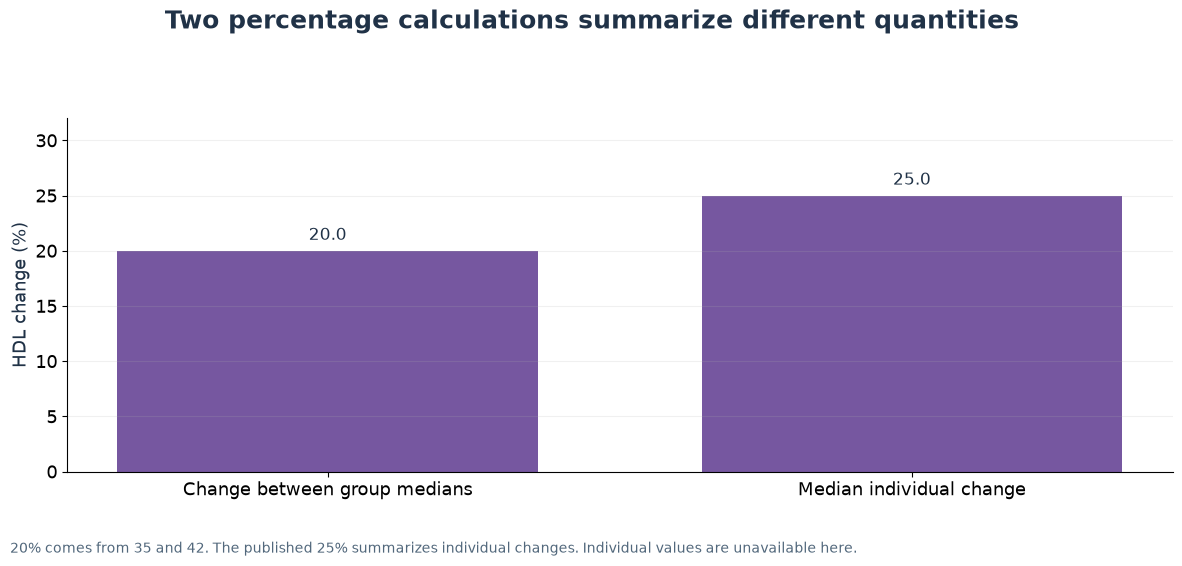

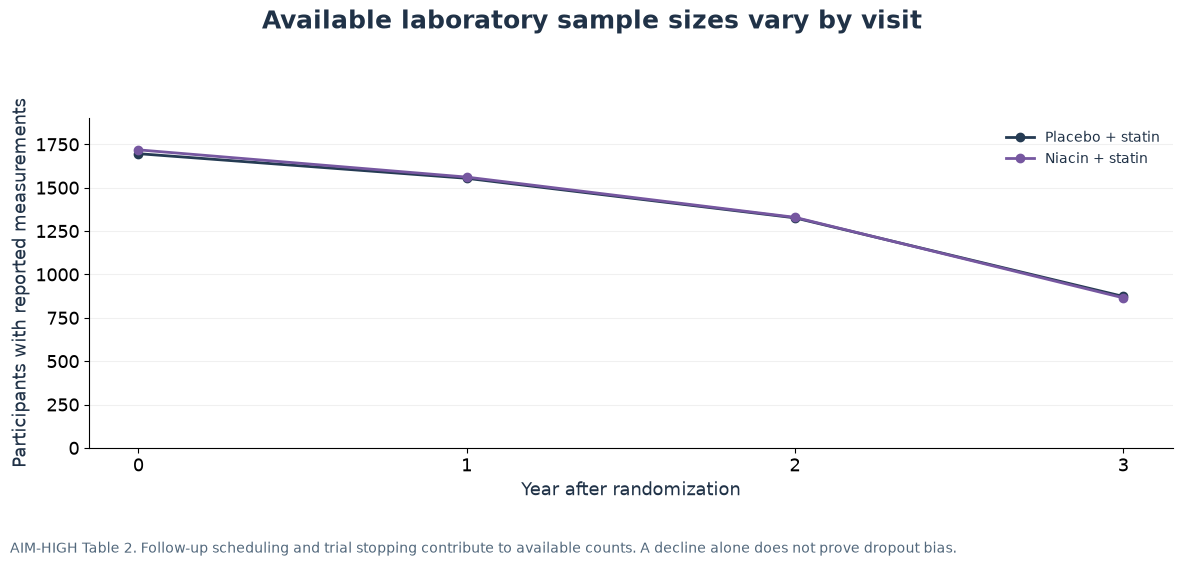

In [14]:
between_medians=100*(42-35)/35
reported_individual=float(tables['aim_high_reported_changes'].query("arm=='Niacin + statin'").median_individual_change_pct.iloc[0])
emit('14_hdl_change_operators','Two percentage calculations summarize different quantities',[
    dict(kind='bar',categories=['Change between group medians','Median individual change'],ylabel='HDL change (%)',
         series=[series('Niacin arm at year two',[between_medians,reported_individual],C['niacin'])],ylim=[0,32])],
    '20% comes from 35 and 42. The published 25% summarizes individual changes. Individual values are unavailable here.',AIM)
ss=[]
for arm,color in [('Placebo + statin',C['control']),('Niacin + statin',C['niacin'])]:
    g=hdl[hdl.arm==arm].sort_values('year');ss.append(series(arm,g.n_measured,color,x=g.year))
emit('15_hdl_measurement_counts','Available laboratory sample sizes vary by visit',[
    dict(kind='line',xlabel='Year after randomization',ylabel='Participants with reported measurements',xticks=[0,1,2,3],ylim=[0,1900],series=ss)],
    'AIM-HIGH Table 2. Follow-up scheduling and trial stopping contribute to available counts. A decline alone does not prove dropout bias.',AIM)

## RUN 12: Actual cardiovascular outcomes resolve the HDL pitch

**Predict before the reveal:** Which arm had fewer affected participants? Calculate each event proportion.

The trial did not demonstrate additional benefit from adding niacin to intensive statin treatment in these patients. This finding does not establish exact equality or prove every possible HDL intervention ineffective.

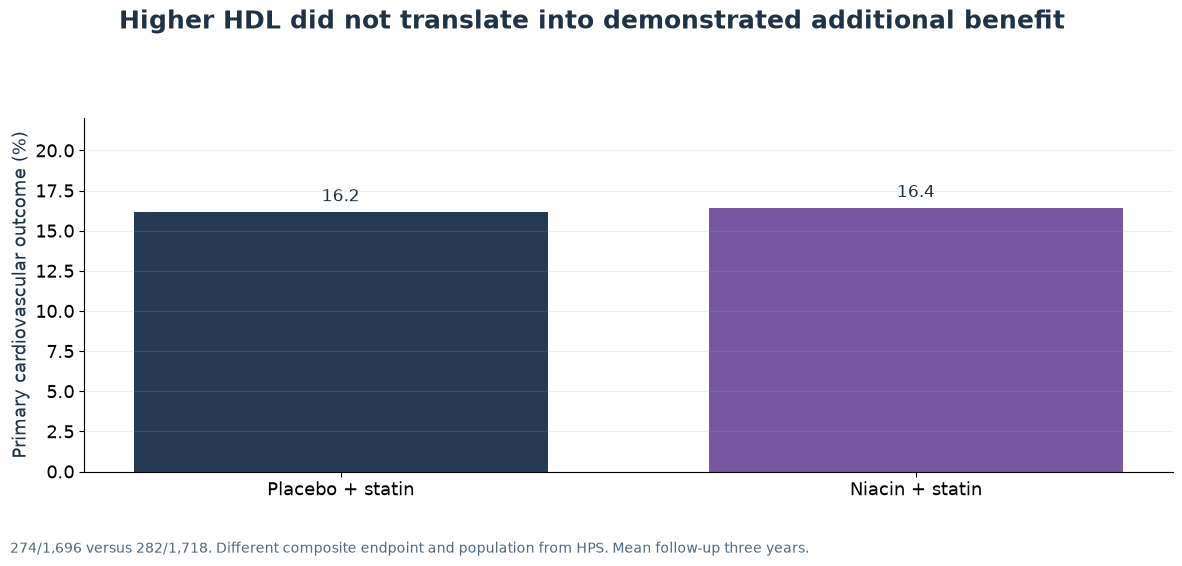

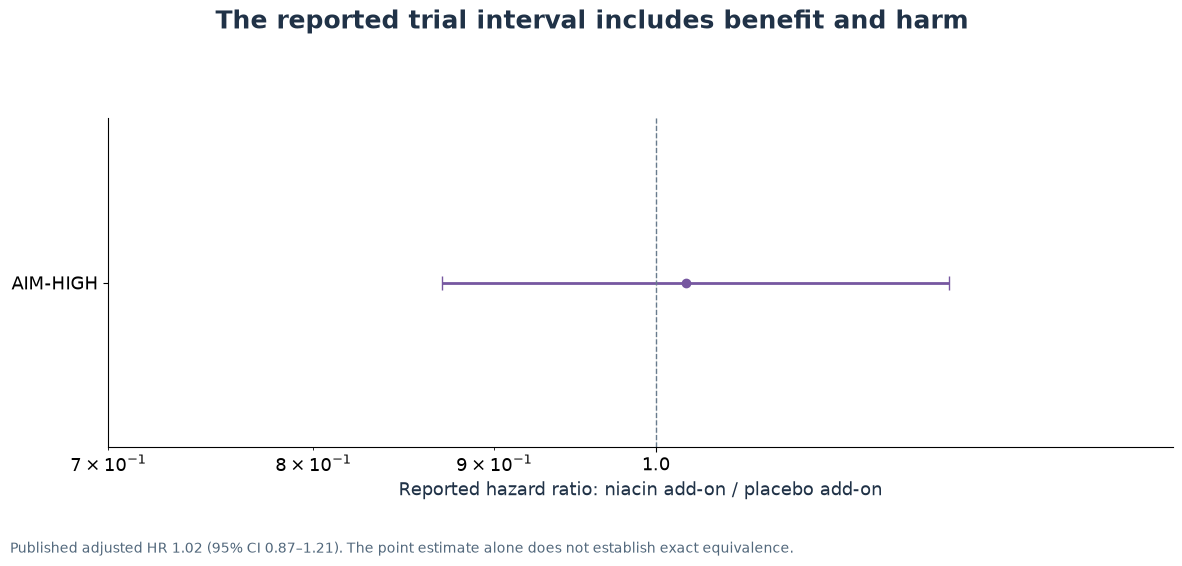

In [15]:
emit('16_hdl_outcomes','Higher HDL did not translate into demonstrated additional benefit',[
    dict(kind='bar',categories=['Placebo + statin','Niacin + statin'],ylabel='Primary cardiovascular outcome (%)',
         series=[dict(series('Event risk',[100*aim['pc'],100*aim['pt']],C['control']),colors=[C['control'],C['niacin']])],ylim=[0,22])],
    '274/1,696 versus 282/1,718. Different composite endpoint and population from HPS. Mean follow-up three years.',AIM)
emit('17_hdl_outcome_interval','The reported trial interval includes benefit and harm',[
    dict(kind='forest',xlabel='Reported hazard ratio: niacin add-on / placebo add-on',yticks=[0],yticklabels=['AIM-HIGH'],xref=1,xscale='log',xlim=[.7,1.4],
         series=[dict(series('Published 95% CI',[1.02],C['niacin'],lower=[.87],upper=[1.21]),y=[0])])],
    'Published adjusted HR 1.02 (95% CI 0.87–1.21). The point estimate alone does not establish exact equivalence.',AIM)

## RUN 13: Derivation of a log-risk-ratio interval

Use a first-order Taylor expansion:

$$\log(\hat p)\approx\log(p)+\frac{\hat p-p}{p}.$$

$$\operatorname{Var}(\log\hat p)\approx\frac{1-p}{np},\quad
\widehat{\operatorname{Var}}(\log\hat p)=\frac1e-\frac1n.$$

For independent arms:

$$SE(\log RR)=\sqrt{\frac1{e_T}-\frac1{n_T}+\frac1{e_C}-\frac1{n_C}}.$$

Form $\log(RR)\pm1.96SE$ and exponentiate. The approximation requires nonzero event counts. Our calculated RR interval and the paper's reported HR interval are different estimators.

,study,rr,rr_low,rr_high,logrr_se
0,HPS,0.786307,0.747018,0.827663,0.026152
1,AIM-HIGH,1.016018,0.872638,1.182955,0.077615


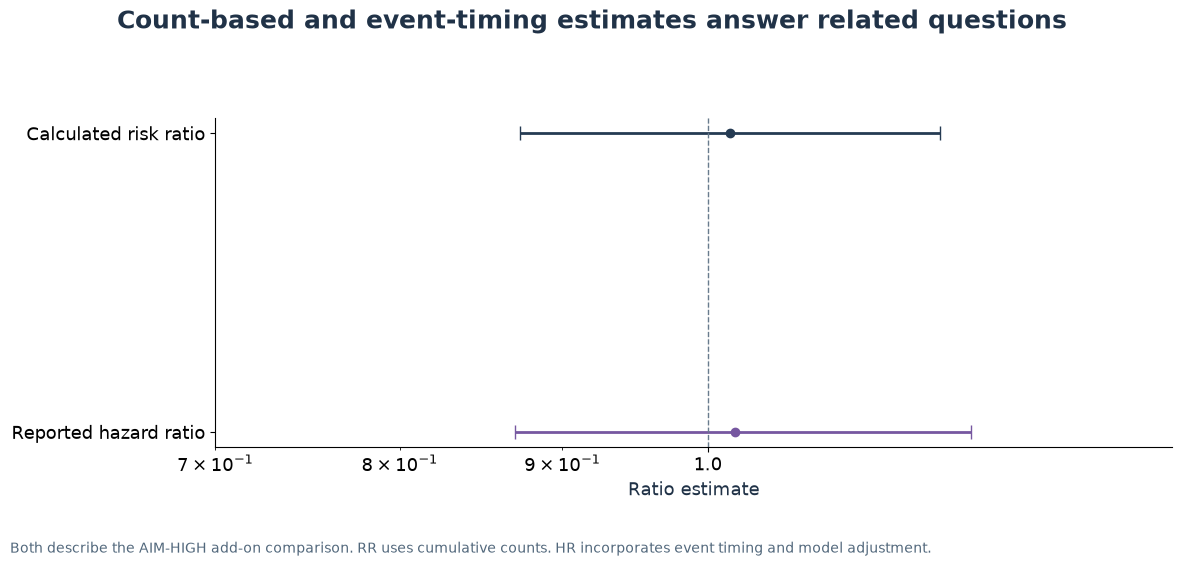

In [16]:
display(pd.DataFrame([hps,aim])[['study','rr','rr_low','rr_high','logrr_se']])
emit('18_hdl_rr_vs_hr','Count-based and event-timing estimates answer related questions',[
    dict(kind='forest',xlabel='Ratio estimate',yticks=[0,1],yticklabels=['Calculated risk ratio','Reported hazard ratio'],xref=1,xscale='log',xlim=[.7,1.4],hide_legend=True,
         series=[dict(series('Cumulative count-based RR',[aim['rr']],C['control'],lower=[aim['rr_low']],upper=[aim['rr_high']]),y=[0]),
                 dict(series('Published adjusted HR',[1.02],C['niacin'],lower=[.87],upper=[1.21]),y=[1])])],
    'Both describe the AIM-HIGH add-on comparison. RR uses cumulative counts. HR incorporates event timing and model adjustment.',AIM)

## RUN 14: Niacin changed more than HDL

The original laboratory table also reports LDL and triglycerides. A selective HDL-only display hides these changes. The randomized trial tests the whole intervention.

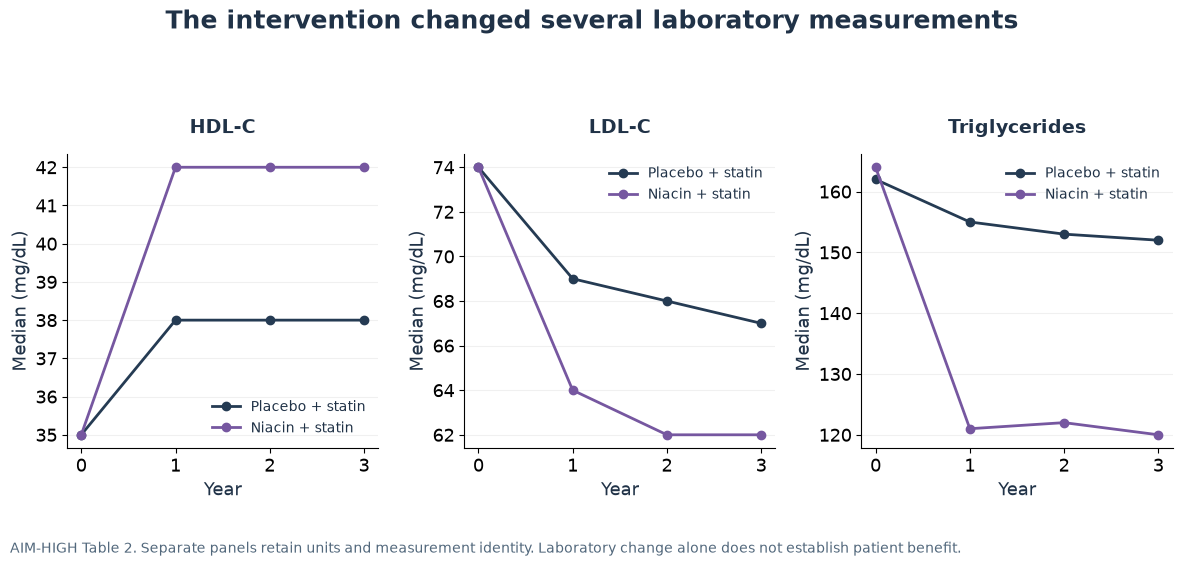

In [17]:
panels=[]
for analyte in ['HDL-C','LDL-C','Triglycerides']:
    ss=[]
    for arm,color in [('Placebo + statin',C['control']),('Niacin + statin',C['niacin'])]:
        g=lipids[(lipids.arm==arm)&(lipids.analyte==analyte)].sort_values('year')
        ss.append(series(arm,g['median'],color,x=g.year))
    panels.append(dict(kind='line',title=analyte,xlabel='Year',ylabel='Median (mg/dL)',xticks=[0,1,2,3],series=ss))
emit('19_lipid_small_multiples','The intervention changed several laboratory measurements',panels,
    'AIM-HIGH Table 2. Separate panels retain units and measurement identity. Laboratory change alone does not establish patient benefit.',AIM)

## RUN 15: Logarithmic geometry and visualization

$$u(r)=\log(r),\qquad u(1)=0,\qquad u(2)=-u(0.5).$$

Equal distances correspond to equal multiplicative changes. The ratio reference is 1. A difference reference is 0. A dot-and-interval plot can use a restricted range with explicit labels.

**Sketch:** place 0.5, 1, and 2 on a linear axis, then on a log axis.

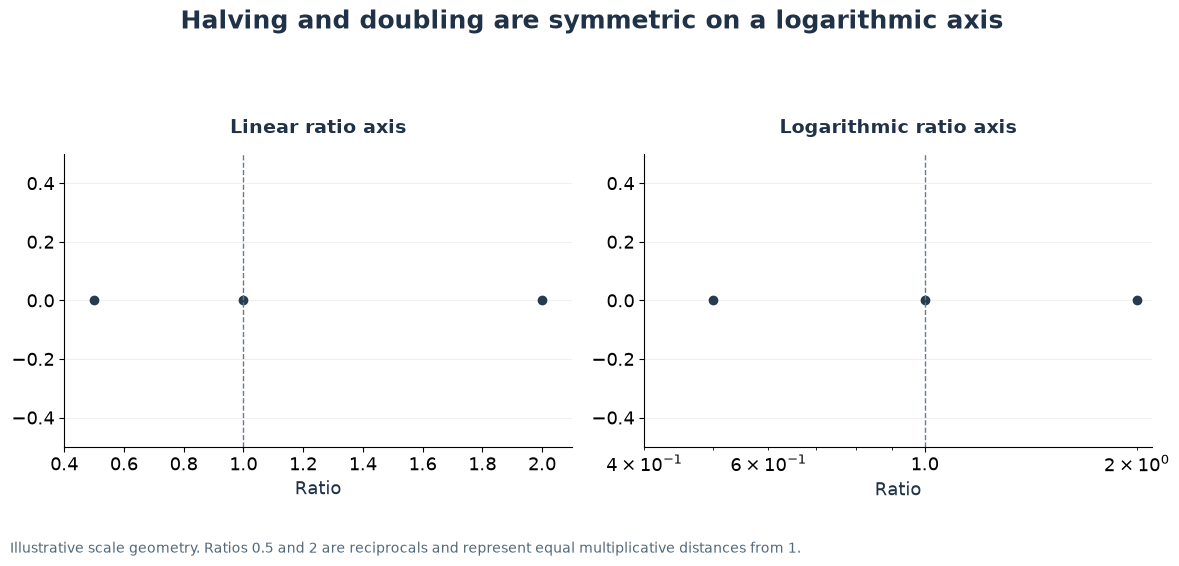

In [18]:
geometry=series('Illustrative ratios',[0,0,0],C['control'],x=[.5,1,2])
emit('20_ratio_geometry','Halving and doubling are symmetric on a logarithmic axis',[
    dict(kind='points',title='Linear ratio axis',xlabel='Ratio',ylabel='',series=[geometry],xlim=[.4,2.1],ylim=[-.5,.5],xref=1),
    dict(kind='points',title='Logarithmic ratio axis',xlabel='Ratio',ylabel='',series=[geometry],xlim=[.4,2.1],ylim=[-.5,.5],xref=1,xscale='log')],
    'Illustrative scale geometry. Ratios 0.5 and 2 are reciprocals and represent equal multiplicative distances from 1.','Mathematical illustration','scale illustration')

# Break

Before leaving, write one sentence explaining why a higher HDL value and better cardiovascular outcomes are different claims.

## RUN 16: What does sugar exposure mean?

This study uses **usual added-sugar energy as a percentage of total calories**. It does not use blood glucose or total dietary sugar.

$$S_{\%}=100\frac{4g_{added}}{E_{total}}.$$

**Arithmetic illustration:** 50 g at 2,000 kcal and 100 g at 4,000 kcal both represent 10%. These two diets are invented examples, separate from the study data.

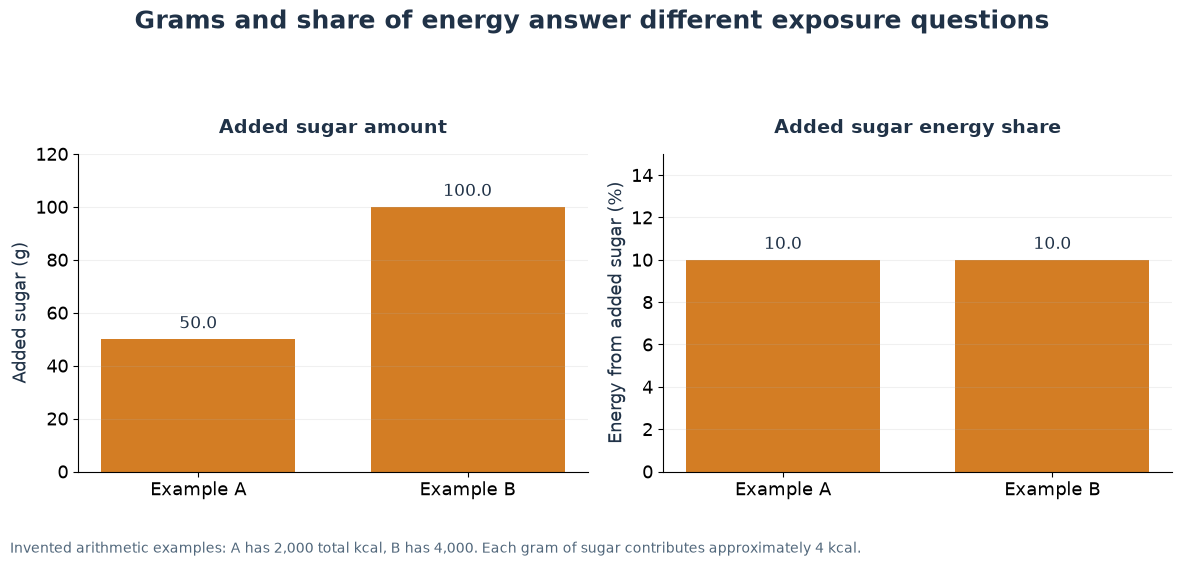

In [19]:
grams=np.array([50,100]);energy=np.array([2000,4000]);shares=100*4*grams/energy
emit('21_sugar_normalization','Grams and share of energy answer different exposure questions',[
    dict(kind='bar',title='Added sugar amount',categories=['Example A','Example B'],ylabel='Added sugar (g)',series=[series('Illustrative diets',grams,C['sugar'])],ylim=[0,120]),
    dict(kind='bar',title='Added sugar energy share',categories=['Example A','Example B'],ylabel='Energy from added sugar (%)',series=[series('Illustrative diets',shares,C['sugar'])],ylim=[0,15])],
    'Invented arithmetic examples: A has 2,000 total kcal, B has 4,000. Each gram of sugar contributes approximately 4 kcal.','Arithmetic illustration','invented arithmetic examples')

## RUN 17: The selective sugar pitch

**Commit:** Does a comparison of only the highest and lowest groups establish that sugar is worse than cholesterol?

The endpoints differ from those in the trials. The displayed number is a model-based hazard ratio for cardiovascular mortality, relative to a reference intake group.

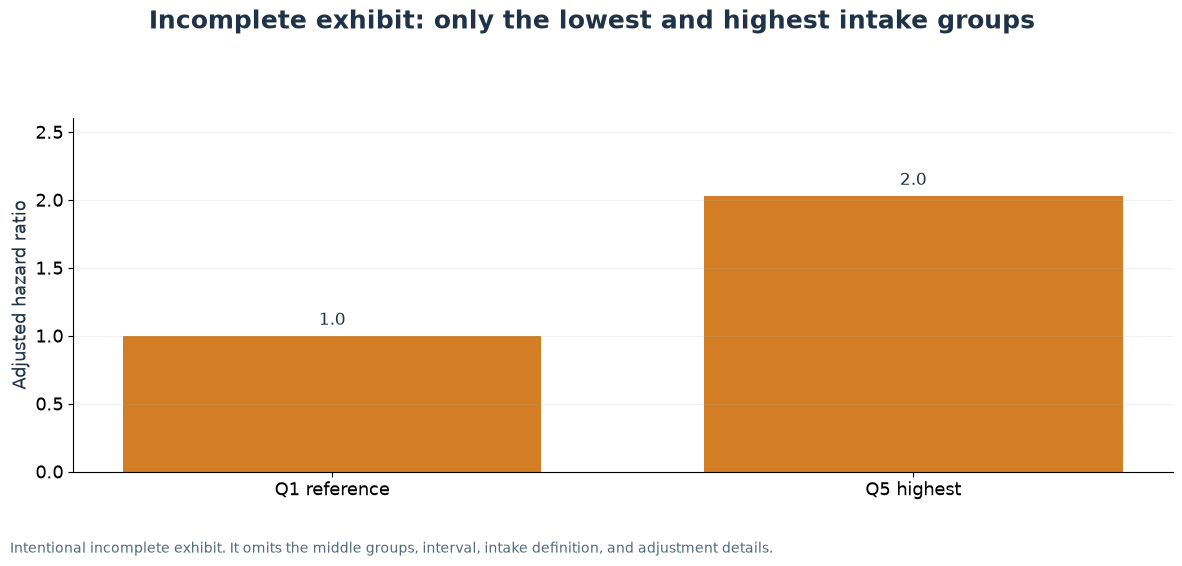

In [20]:
full=sugar[sugar.model=='Full reported adjustment'].copy()
emit('22_sugar_selective','Incomplete exhibit: only the lowest and highest intake groups',[
    dict(kind='bar',categories=['Q1 reference','Q5 highest'],ylabel='Adjusted hazard ratio',
         series=[series('Selected endpoints',[1,2.03],C['sugar'])],ylim=[0,2.6])],
    'Intentional incomplete exhibit. It omits the middle groups, interval, intake definition, and adjustment details.',SUGAR)

## RUN 18: The full exposure pattern and uncertainty

The quintile midvalues are 7.4%, 11.4%, 14.8%, 18.7%, and 25.2%. Place them at their numerical positions. The highest group's 25.2% is a midvalue, not a category threshold.

**Interpret:** describe the direction, reference, interval, outcome, and adjustment model. Do not claim the interval establishes a sugar intervention effect.

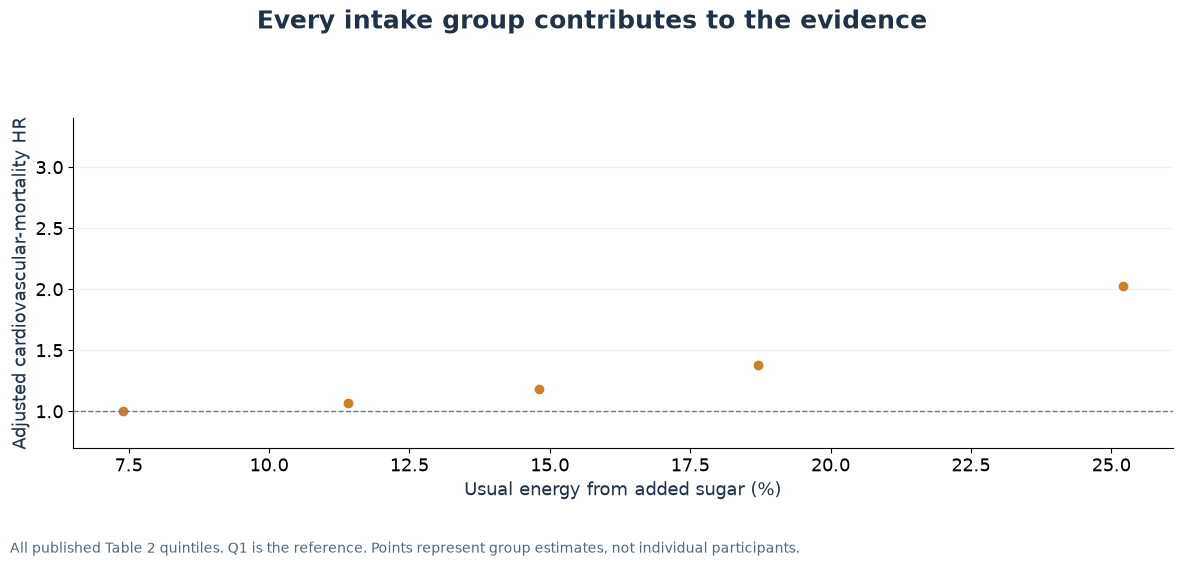

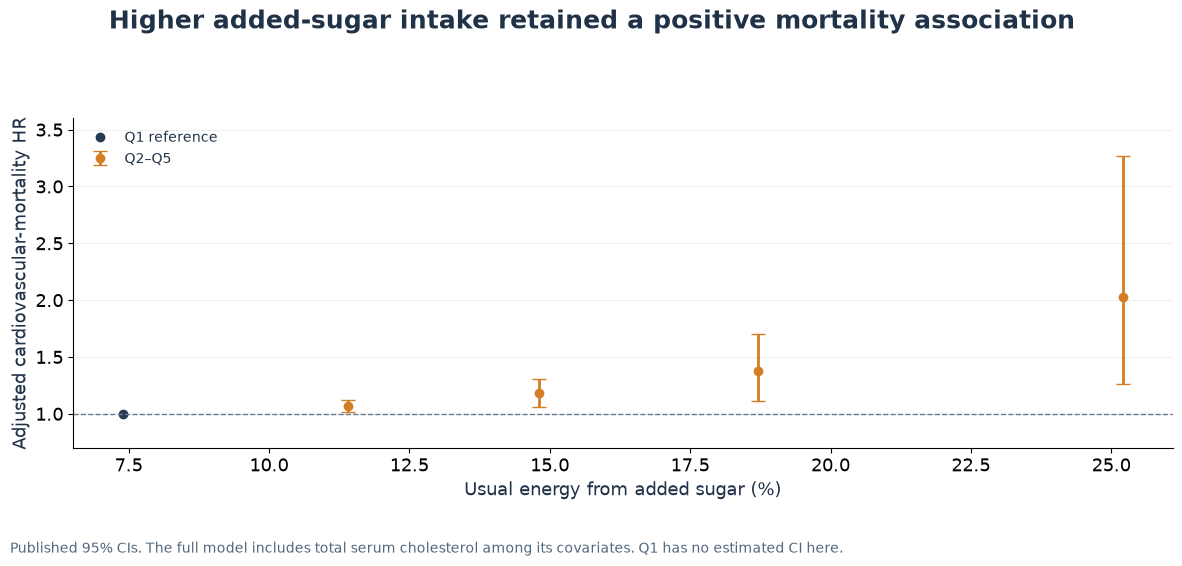

In [21]:
emit('23_sugar_all_groups','Every intake group contributes to the evidence',[
    dict(kind='points',xlabel='Usual energy from added sugar (%)',ylabel='Adjusted cardiovascular-mortality HR',
        series=[series('Full reported adjustment',full.hr,C['sugar'],x=full.midvalue_energy_pct)],ylim=[.7,3.4],yref=1)],
    'All published Table 2 quintiles. Q1 is the reference. Points represent group estimates, not individual participants.',SUGAR)
nonref=full[~full.reference]
emit('24_sugar_intervals','Higher added-sugar intake retained a positive mortality association',[
    dict(kind='points',xlabel='Usual energy from added sugar (%)',ylabel='Adjusted cardiovascular-mortality HR',
        series=[series('Q2–Q5',nonref.hr,C['sugar'],x=nonref.midvalue_energy_pct,lower=nonref.ci_low,upper=nonref.ci_high),
                series('Q1 reference',[1],C['control'],x=[7.4])],ylim=[.7,3.6],yref=1)],
    'Published 95% CIs. The full model includes total serum cholesterol among its covariates. Q1 has no estimated CI here.',SUGAR)

## RUN 19: Adjustment changes the estimate, while the association remains

Both published models include adjustment. The first adjusts for demographics. The second includes additional behavioral and clinical factors, including total serum cholesterol.

**Explain:** Why does the change from 2.43 to 2.03 not identify the isolated contribution of cholesterol? Several covariates change together.

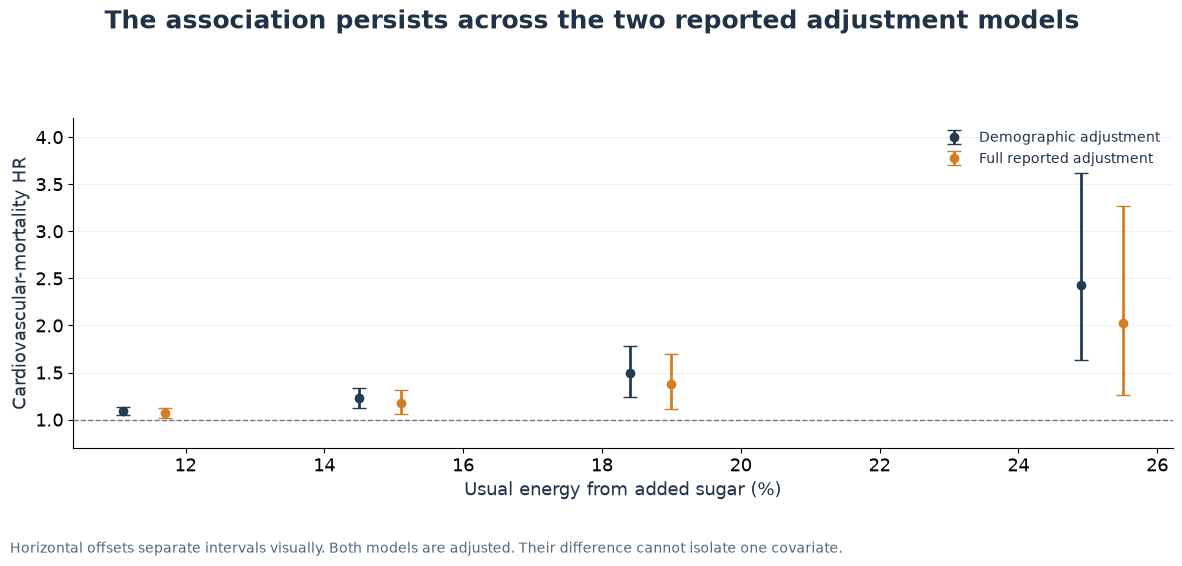

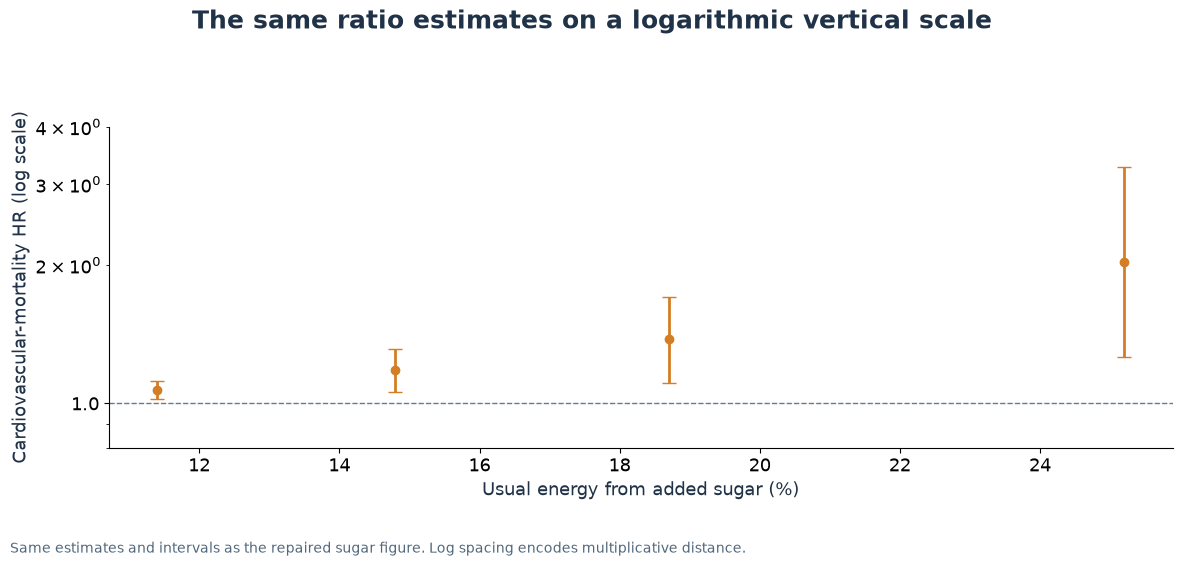

In [22]:
ss=[]
for model,color,shift in [('Demographic adjustment',C['control'],-.3),('Full reported adjustment',C['sugar'],.3)]:
    g=sugar[(sugar.model==model)&(~sugar.reference)]
    ss.append(series(model,g.hr,color,x=g.midvalue_energy_pct+shift,lower=g.ci_low,upper=g.ci_high))
emit('25_sugar_models','The association persists across the two reported adjustment models',[
    dict(kind='points',xlabel='Usual energy from added sugar (%)',ylabel='Cardiovascular-mortality HR',series=ss,ylim=[.7,4.2],yref=1)],
    'Horizontal offsets separate intervals visually. Both models are adjusted. Their difference cannot isolate one covariate.',SUGAR)
emit('26_sugar_log','The same ratio estimates on a logarithmic vertical scale',[
    dict(kind='points',xlabel='Usual energy from added sugar (%)',ylabel='Cardiovascular-mortality HR (log scale)',
        series=[series('Full reported adjustment',nonref.hr,C['sugar'],x=nonref.midvalue_energy_pct,lower=nonref.ci_low,upper=nonref.ci_high)],
        ylim=[.8,4],yscale='log',yref=1)],
    'Same estimates and intervals as the repaired sugar figure. Log spacing encodes multiplicative distance.',SUGAR)

## RUN 20: Risk and hazard are different quantities

$$P(T\le t)\quad\text{is cumulative risk},$$

$$h(t)=\lim_{\Delta t\to0}\frac{P(t\le T<t+\Delta t\mid T\ge t)}{\Delta t}.$$

A hazard ratio compares conditional instantaneous rates. The sugar study's 2.03 does not tell us an absolute probability without baseline risk and the model. Under proportional hazards, $S_E(t)=S_R(t)^{HR}$, so $R_E(t)=1-[1-R_R(t)]^{HR}$.

The next plot is a clearly labeled mathematical illustration using HR 2.03. It does not reconstruct the study's risks or survival curves.

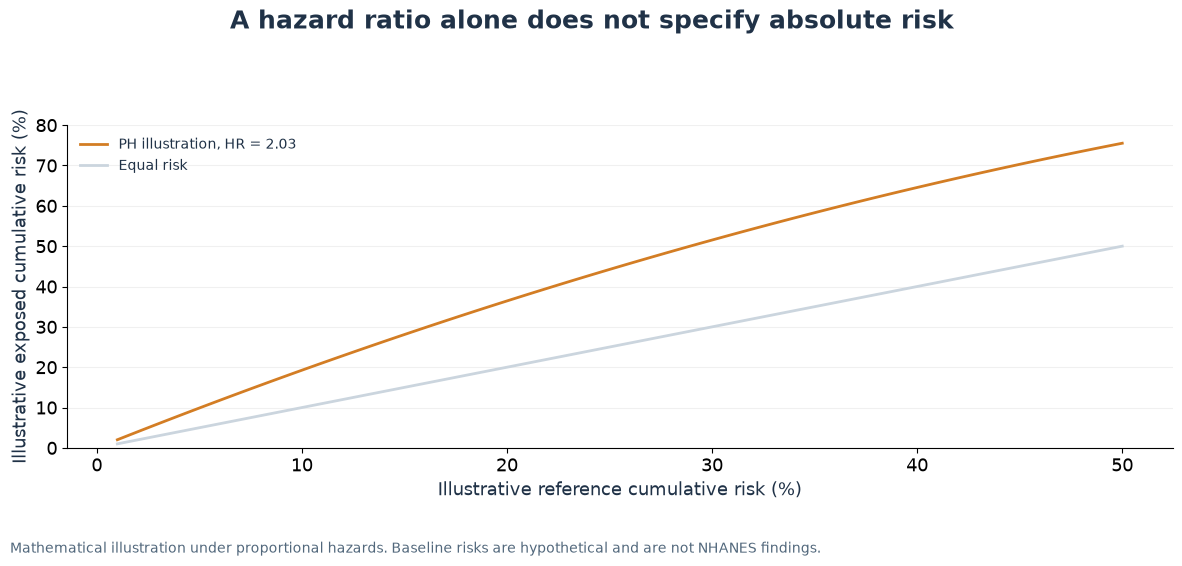

In [23]:
baseline=np.linspace(.01,.5,80);exposed=1-(1-baseline)**2.03
emit('27_hazard_to_risk','A hazard ratio alone does not specify absolute risk',[
    dict(kind='curve',xlabel='Illustrative reference cumulative risk (%)',ylabel='Illustrative exposed cumulative risk (%)',
         series=[series('PH illustration, HR = 2.03',100*exposed,C['sugar'],x=100*baseline),
                 series('Equal risk',100*baseline,C['muted'],x=100*baseline)],ylim=[0,80])],
    'Mathematical illustration under proportional hazards. Baseline risks are hypothetical and are not NHANES findings.',SUGAR,'model illustration with hypothetical baseline risks')

## RUN 21: The story closes with three findings

1. Randomized LDL-lowering treatment reduced major vascular events in HPS.
2. AIM-HIGH's HDL-raising add-on did not demonstrate additional cardiovascular benefit.
3. Higher added-sugar intake retained a positive cardiovascular-mortality association after adjustment including total cholesterol in the cohort study.

The scientific evidence for LDL causality is broader than our single trial: [genetic, epidemiologic, and intervention evidence](https://pmc.ncbi.nlm.nih.gov/articles/5837225/). Sugar's association does not make LDL harmless. A larger HDL number alone does not establish protection.

**Figure choice:** These studies have different populations, endpoints, and estimators. Give them separately labeled panels. Do not pool their results or rank their effect sizes as a danger contest.

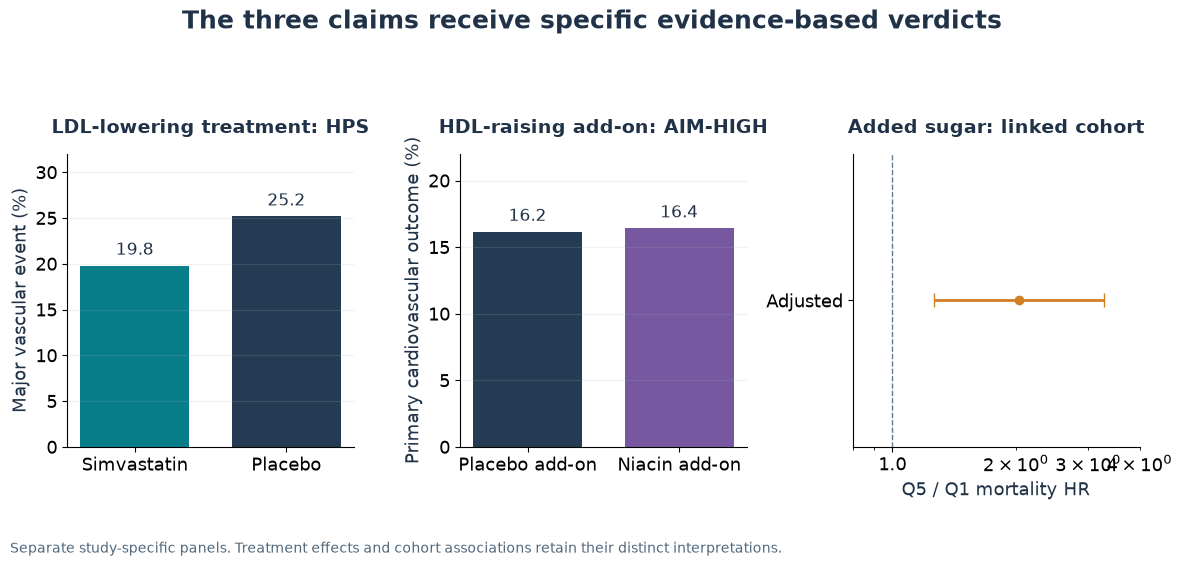

In [24]:
emit('28_final_evidence','The three claims receive specific evidence-based verdicts',[
    dict(kind='bar',title='LDL-lowering treatment: HPS',categories=['Simvastatin','Placebo'],ylabel='Major vascular event (%)',
         series=[dict(series('Event risk',[100*hps['pt'],100*hps['pc']],C['treatment']),colors=[C['treatment'],C['control']])],ylim=[0,32]),
    dict(kind='bar',title='HDL-raising add-on: AIM-HIGH',categories=['Placebo add-on','Niacin add-on'],ylabel='Primary cardiovascular outcome (%)',
         series=[dict(series('Event risk',[100*aim['pc'],100*aim['pt']],C['control']),colors=[C['control'],C['niacin']])],ylim=[0,22]),
    dict(kind='forest',title='Added sugar: linked cohort',xlabel='Q5 / Q1 mortality HR',yticks=[0],yticklabels=['Adjusted'],xref=1,xscale='log',xlim=[.8,4],
         series=[dict(series('Published 95% CI',[2.03],C['sugar'],lower=[1.26],upper=[3.27]),y=[0])])],
    'Separate study-specific panels. Treatment effects and cohort associations retain their distinct interpretations.',HPS+'; '+AIM+'; '+SUGAR)

## RUN 22: Export the evidence

The figure manifest records plotted values and labels. Count-based results remain separate from published timing-model estimates. The source tables retain their original source references.

In [25]:
summary=pd.DataFrame([hps,aim])
summary.to_csv(OUT/'computed_trial_effects.csv',index=False)
ldl_effects.to_csv(OUT/'computed_ldl_subgroups.csv',index=False)
(OUT/'results.json').write_text(json.dumps({'hps':hps,'aim_high':aim,'figure_count':len(CHARTS)},indent=2)+'\n')
(OUT/'chart_data.json').write_text(json.dumps(CHARTS,indent=2)+'\n')
assert len(CHARTS)==28
assert hps['arr_low']>0
assert aim['rr_low']<1<aim['rr_high']
assert full.iloc[-1].ci_low>1
print(f'Exported {len(CHARTS)} figures with reproducible plotted values.')

Exported 28 figures with reproducible plotted values.


## Student evidence brief

Choose one incomplete pitch. Deliver a corrected figure and three sentences:

1. State the finding.
2. Give the effect, reference, denominator or interval that supports it.
3. Name the study population and the scope of the inference.

Then answer the original combined question: explain why the evidence supports multiple contributors rather than replacing cholesterol with sugar as the only culprit.